<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/Metod_Newton_Convergencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Digite o valor inicial x0: -1.6


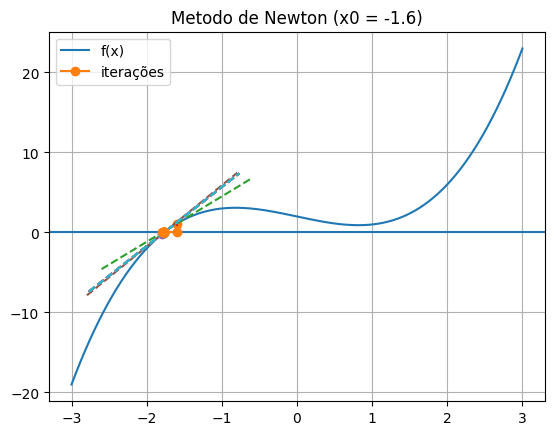


Iterações:
x_0 = -1.6
x_1 = -1.7943661971830984
x_2 = -1.769732159341582
x_3 = -1.7692924930819278
x_4 = -1.7692923542386454
x_5 = -1.7692923542386314
x_6 = -1.7692923542386314
x_7 = -1.7692923542386314
x_8 = -1.7692923542386314
x_9 = -1.7692923542386314
x_10 = -1.7692923542386314


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Método de Newton
# ============================
# Exemplo: convergência se x0 próximo a raiz / divergência se x0 longe da raiz
# Longe da vizinhança da raiz não se pode garantir que g(x)=x-f(x)/f'(x)
# seja contração e o teorema do ponto fixo de Banach não pode ser aplicado.
# f(x) = x³ - 2x + 2 possui raiz ~ -1.769
# f'(x) = 3x² - 2

# Função e derivada
def f(x):
    return x**3 - 2*x + 2

def df(x):
    return 3*x**2 - 2

# Método de Newton
def newton(x0, n_iter=10):
    xs = [x0]
    x = x0
    for _ in range(n_iter):
        x = x - f(x)/df(x)
        xs.append(x)
    return xs

# ============================
# ESCOLHA DO CHUTE INICIAL
# ============================
x0 = float(input("Digite o valor inicial x0: "))

# Calcula iterações
xs = newton(x0, n_iter=10)

# Intervalo para gráfico
x_plot = np.linspace(-3, 3, 400)
y_plot = f(x_plot)

# Plot
plt.figure()
plt.axhline(0)  # eixo x
plt.plot(x_plot, y_plot, label="f(x)")

# Plot das iterações
for i in range(len(xs)-1):
    # ponto atual
    plt.plot(xs[i], f(xs[i]), 'o')

    # reta tangente (aproximação)
    x_tan = np.linspace(xs[i]-1, xs[i]+1, 100)
    y_tan = f(xs[i]) + df(xs[i])*(x_tan - xs[i])
    plt.plot(x_tan, y_tan, '--')

    # linha vertical até eixo x (passo de Newton)
    plt.plot([xs[i], xs[i]], [f(xs[i]), 0], ':')

# pontos finais no eixo x
plt.plot(xs, [0]*len(xs), 'o-', label="iterações")

plt.title(f"Metodo de Newton (x0 = {x0})")
plt.legend()
plt.grid()

plt.show()

# Mostrar valores numéricos
print("\nIterações:")
for i, val in enumerate(xs):
    print(f"x_{i} = {val}")